# 03 — Visualizations
Loads the cleaned data from `02_data_clean_visualize_me_search.ipynb` and produces all maps.

In [55]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path
from scipy import stats
import numpy as np



# Find the repo root by searching upward for README.md
# This works no matter where Jupyter is launched from
def find_repo_root(start=Path().resolve()):
    for parent in [start] + list(start.parents):
        if (parent / "README.md").exists() and (parent / "data").exists():
            return parent
    raise FileNotFoundError("Could not find repo root — make sure README.md and data/ exist.")

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

print("Working directory:", os.getcwd())
print("Files in data/:", os.listdir('data'))

Working directory: /Users/charlottewest/Documents/QSS20-CW-Final
Files in data/: ['cleaned_data', 'final_clean_race.csv', '.DS_Store', 'final_map.csv', '01_pulls', 'raw', 'nj_pfas_map.png']


## Load cleaned data

In [56]:
# Load shapefile and cleaned data, then merge
# Drop the text geometry column from the CSV — the real geometry comes from the GeoJSON
nj_shapes = gpd.read_file('data/01_pulls/nj_zcta_2024.geojson')
final_df  = pd.read_csv('data/cleaned_data/final_map.csv', dtype={'ZIPCODE': str})
final_df  = final_df.drop(columns=[c for c in final_df.columns if 'geometry' in c.lower()])

map_df = nj_shapes.merge(final_df, on='ZIPCODE', how='left')
map_df = map_df.set_geometry('geometry')

print(map_df.columns.tolist())

['ZIPCODE', 'GEOID20_x', 'GEOIDFQ20_x', 'CLASSFP20_x', 'MTFCC20_x', 'FUNCSTAT20_x', 'ALAND20_x', 'AWATER20_x', 'INTPTLAT20_x', 'INTPTLON20_x', 'geometry', 'GEOID20_y', 'GEOIDFQ20_y', 'CLASSFP20_y', 'MTFCC20_y', 'FUNCSTAT20_y', 'ALAND20_y', 'AWATER20_y', 'INTPTLAT20_y', 'INTPTLON20_y', 'max_pfas', 'mean_pfas', 'total_detections', 'num_contaminants', 'NAME', 'total_pop', 'pct_white', 'pct_black', 'pct_native', 'pct_asian', 'pct_pacific_islander', 'pct_hispanic', 'pct_nonhispanic_white', 'pct_minority', 'exceeds_mcl', 'exceeds_mcl_mean', 'exceeds_mcl_max']


## Mean PFAS concentration by ZIP (µg/L)

It should be noted that the MCL for PFAS is 0.004 ppb (which is what all of these graphs are in)

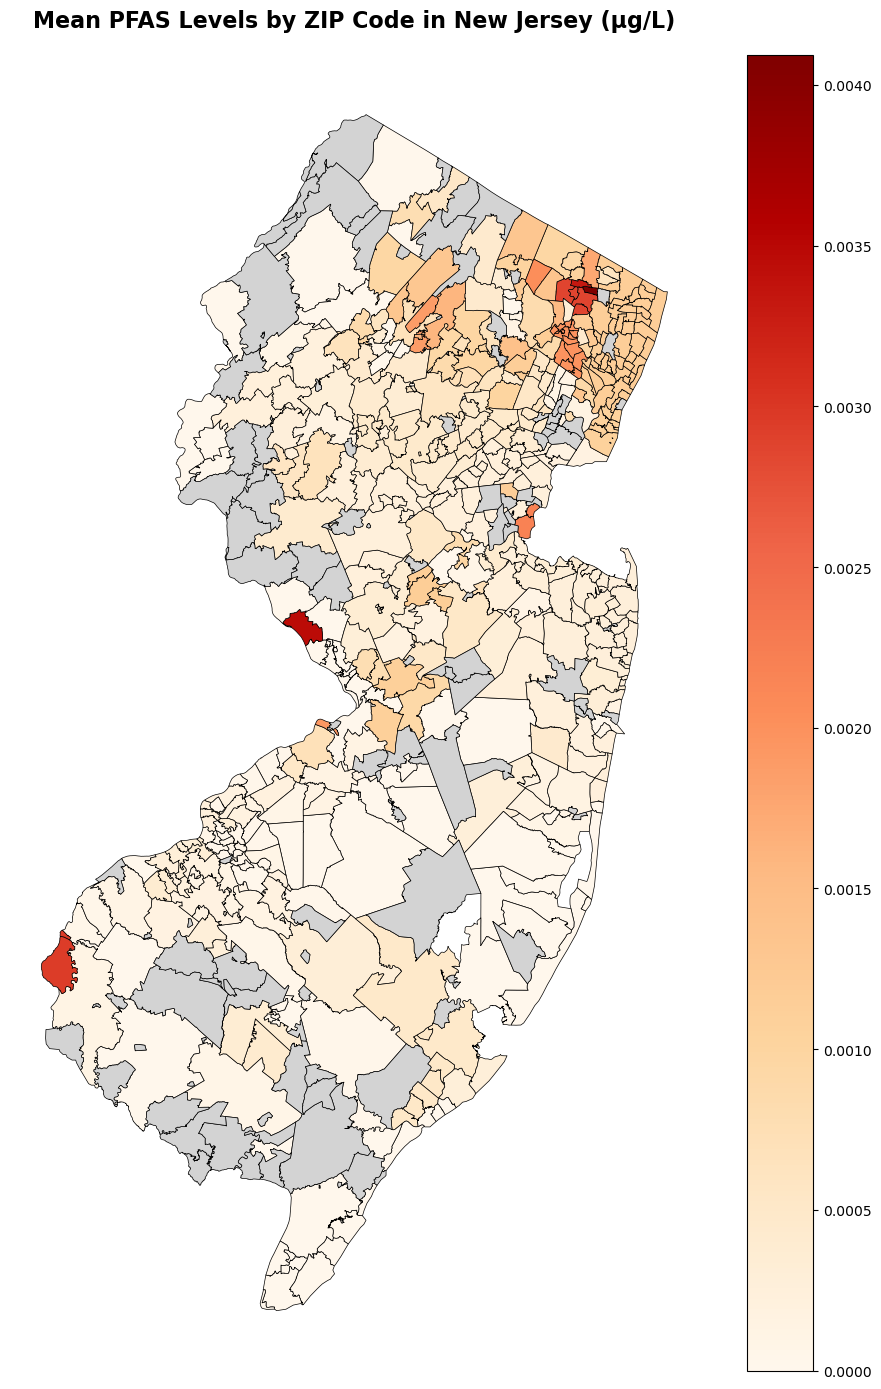

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

map_df.plot(
    column       = 'mean_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'No Data'},
    ax           = ax
)

ax.set_title('Mean PFAS Levels by ZIP Code in New Jersey (µg/L)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_map_mean.png', dpi=300, bbox_inches='tight')
plt.show()

## Max PFAS concentration by ZIP (µg/L)

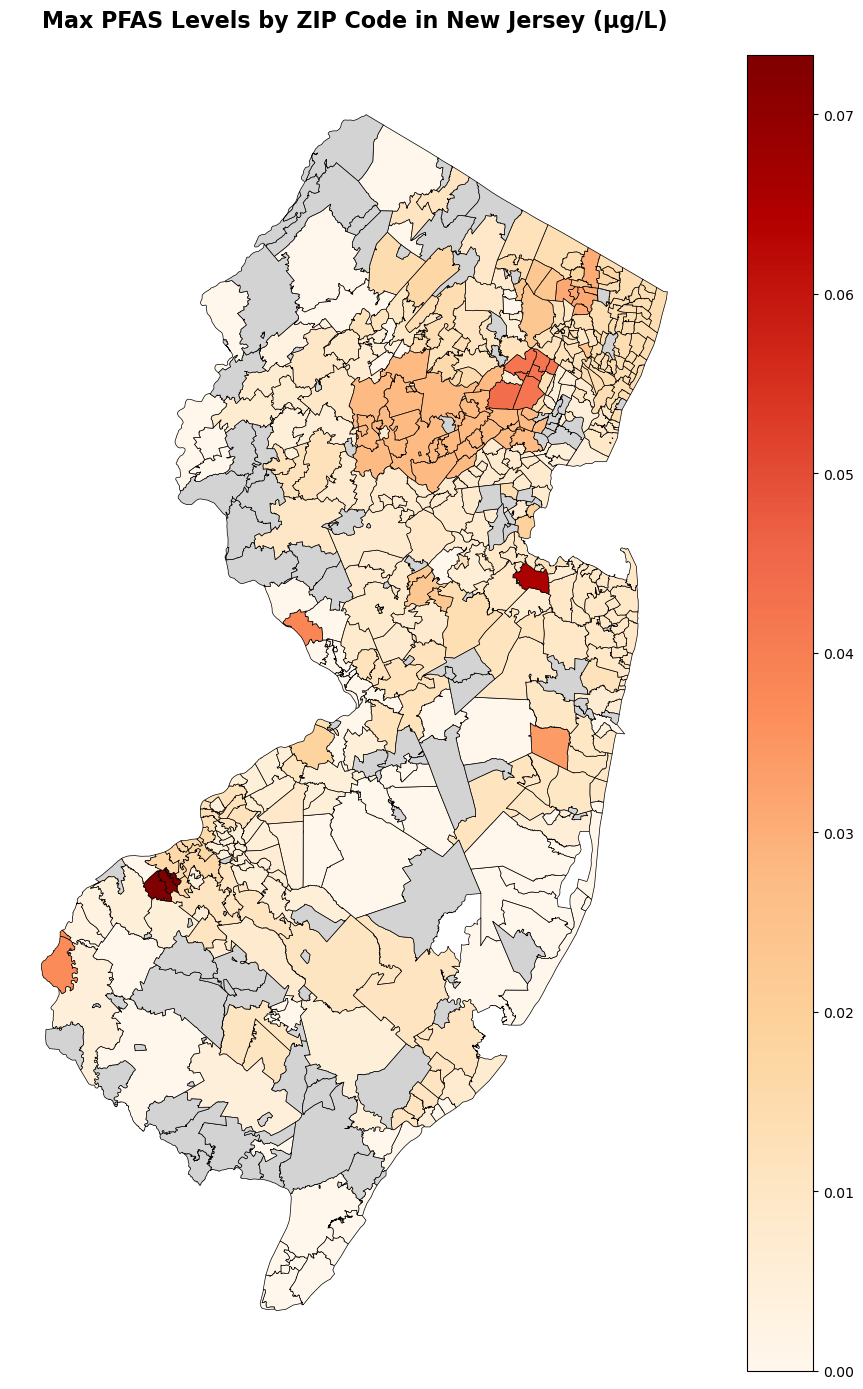

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

map_df.plot(
    column       = 'max_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'No Data'},
    ax           = ax
)

ax.set_title('Max PFAS Levels by ZIP Code in New Jersey (µg/L)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_map_max.png', dpi=300, bbox_inches='tight')
plt.show()

## Max binary map ZIP codes exceeding EPA MCL (0.004 µg/L)

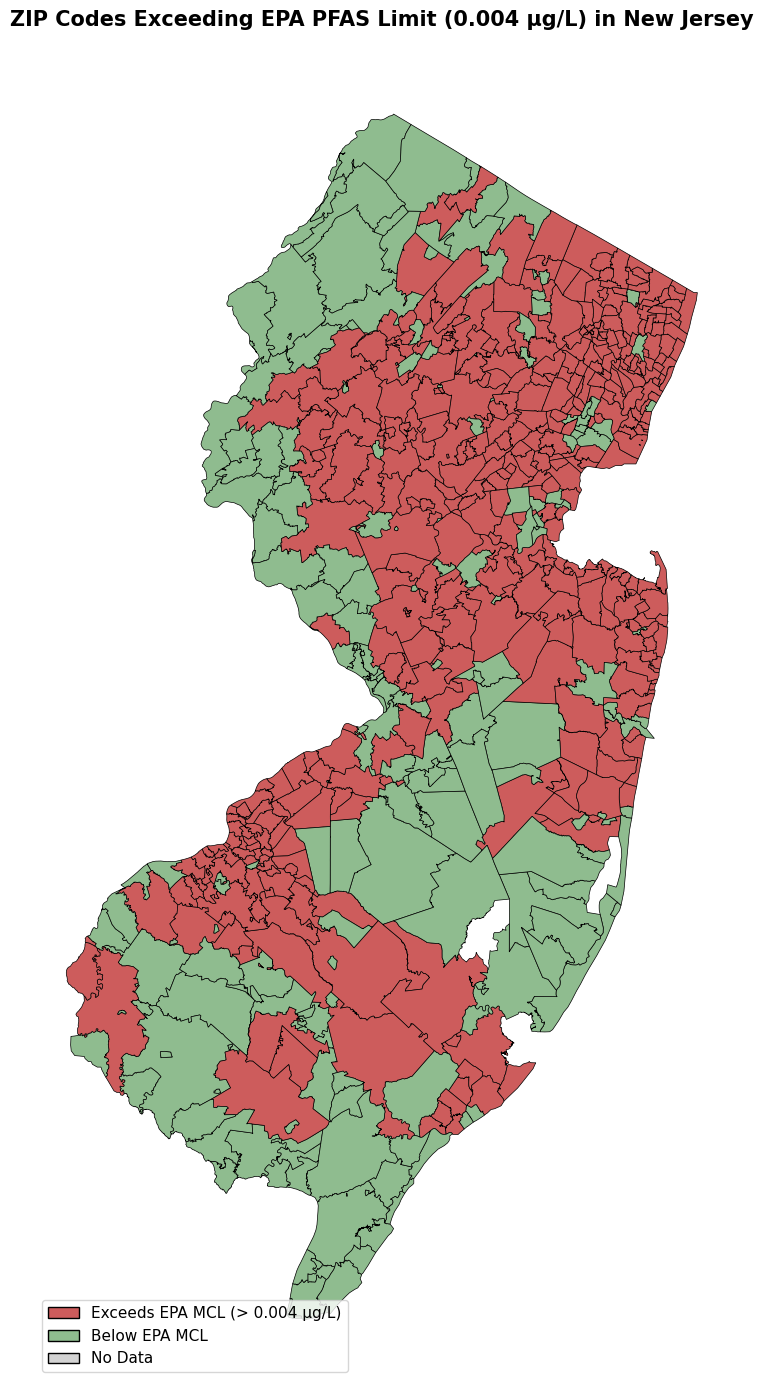

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

cmap_binary = ListedColormap(['darkseagreen', 'indianred'])

map_df.plot(
    column       = 'exceeds_mcl_max',
    cmap         = cmap_binary,
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = False,
    missing_kwds = {'color': 'lightgrey'},
    ax           = ax
)

legend_elements = [
    Patch(facecolor='indianred', edgecolor='black', label='Exceeds EPA MCL (> 0.004 µg/L)'),
    Patch(facecolor='darkseagreen', edgecolor='black', label='Below EPA MCL'),
    Patch(facecolor='lightgrey', edgecolor='black', label='No Data'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11)

ax.set_title('ZIP Codes Exceeding EPA PFAS Limit (0.004 µg/L) in New Jersey',
             fontsize=15, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_exceeds_mcl.png', dpi=300, bbox_inches='tight')
plt.show()

## PFAS contamination vs race (side by side)

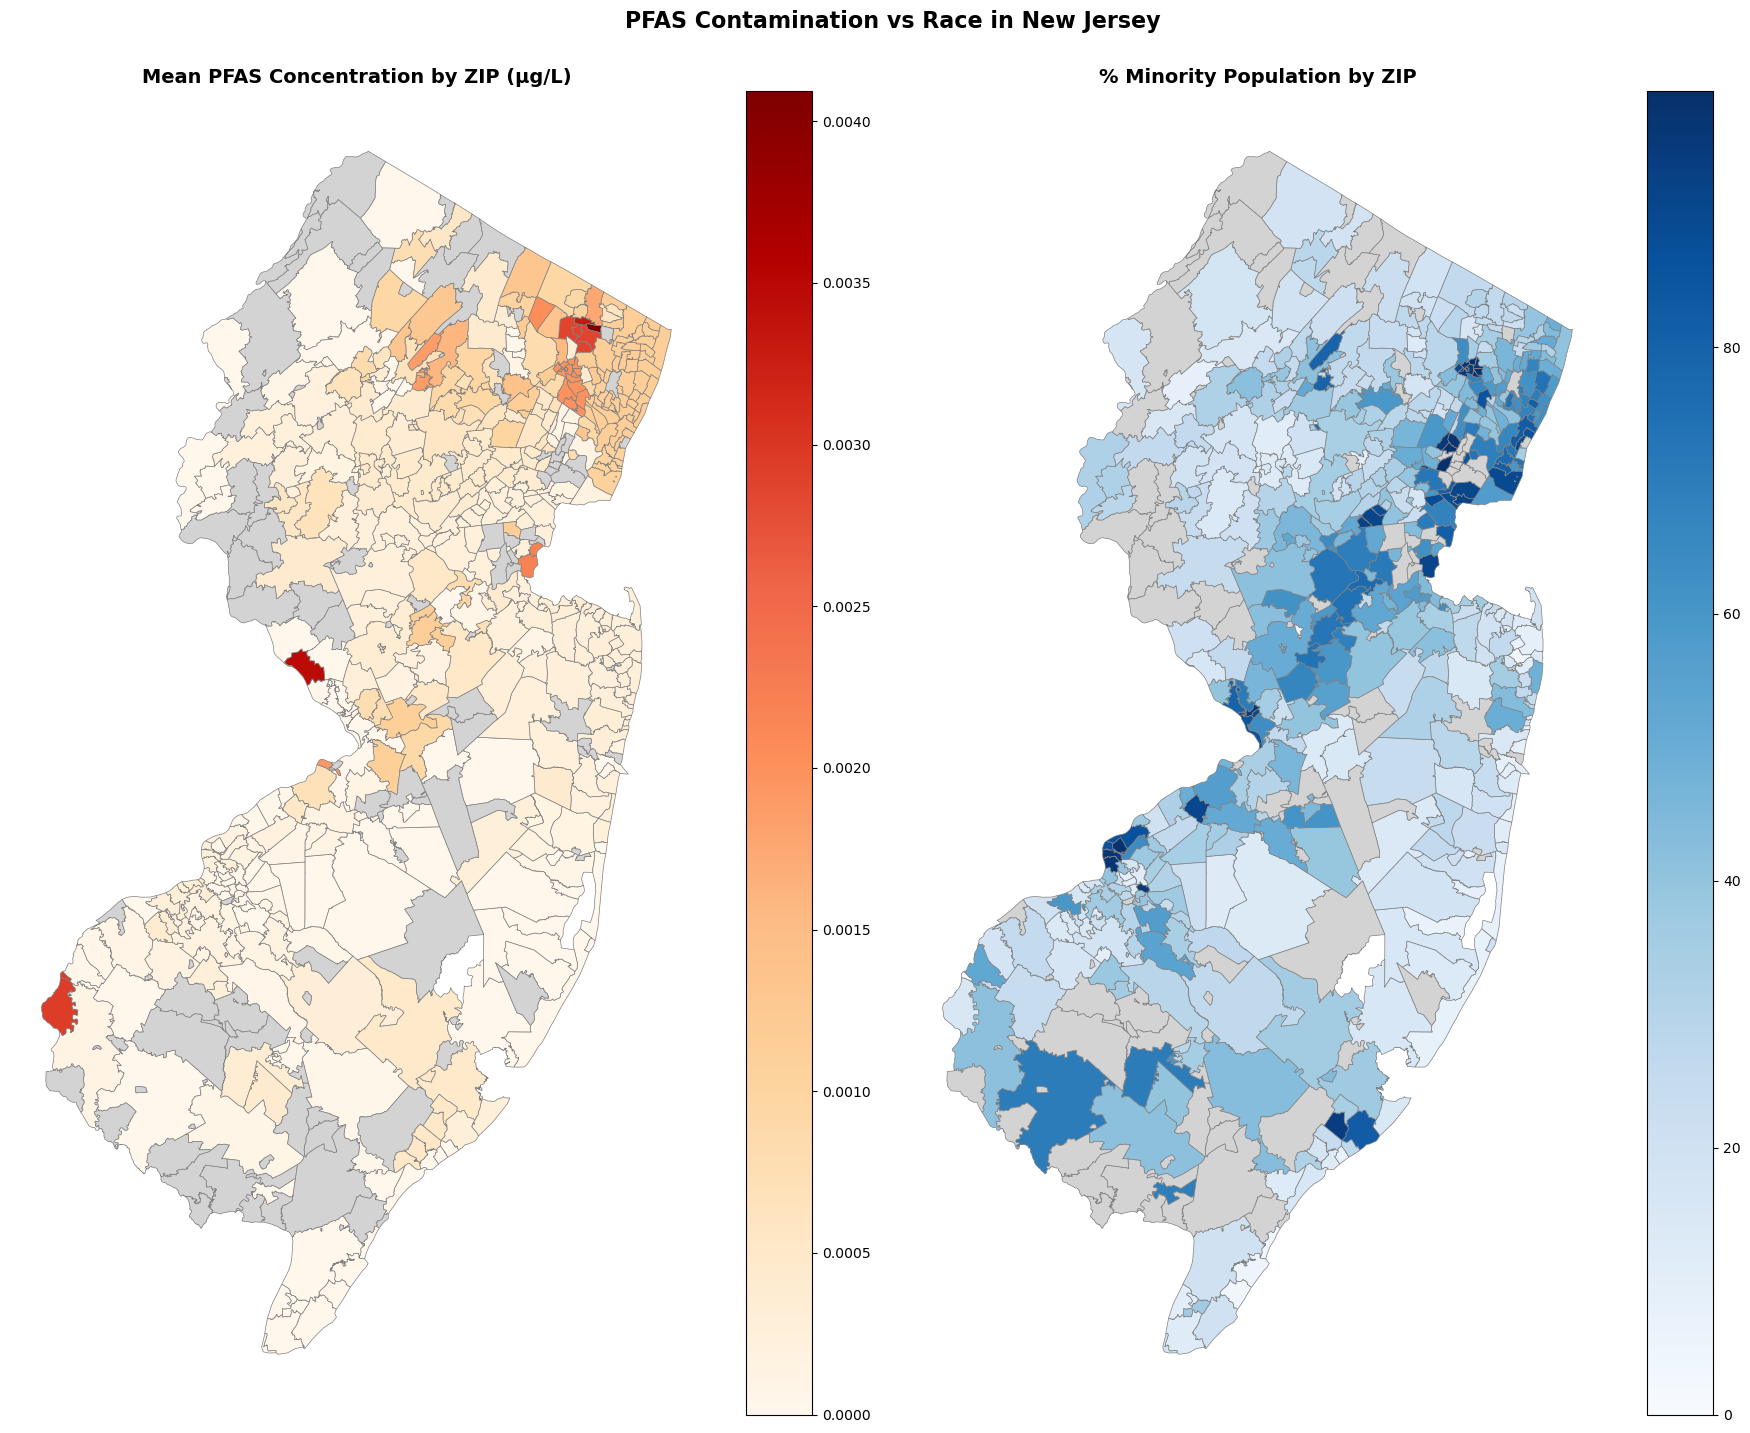

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Left — mean PFAS
map_df.plot(
    column       = 'mean_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[0]
)
legend = axes[0].get_legend()
if legend is not None:
    legend.set_title('PFAS (µg/L)', prop={'size': 10})
axes[0].set_title('Mean PFAS Concentration by ZIP (µg/L)', fontsize=14, fontweight='bold')
axes[0].set_axis_off()

# Right — % minority
map_df.plot(
    column       = 'pct_minority',
    cmap         = 'Blues',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[1]
)
legend = axes[1].get_legend()
if legend is not None:
    legend.set_title('% Minority', prop={'size': 10})
axes[1].set_title('% Minority Population by ZIP', fontsize=14, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('PFAS Contamination vs Race in New Jersey',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/nj_pfas_vs_race_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Pearsons Correlation Test

In [61]:
from scipy import stats
import pandas as pd

# Drop rows where either value is missing
pt_df = map_df[['mean_pfas', 'max_pfas','pct_minority', 'pct_black','pct_hispanic']].dropna()

pt_df['mean_pfas'] = pd.to_numeric(pt_df['mean_pfas'], errors='coerce')
pt_df['max_pfas'] = pd.to_numeric(pt_df['max_pfas'], errors = 'coerce')
pt_df['pct_minority'] = pd.to_numeric(pt_df['pct_minority'], errors='coerce')
pt_df['pct_black'] = pd.to_numeric(pt_df['pct_black'], errors='coerce')
pt_df['pct_hispanic'] = pd.to_numeric(pt_df['pct_hispanic'], errors='coerce')
pt_df = pt_df.dropna()

PFAS and Minority

In [35]:
corr, pvalue = stats.pearsonr(pt_df['mean_pfas'], pt_df['pct_minority'])

print(f'Pearson r:   {corr:.3f}')
print(f'P-value:     {pvalue:.4f}')

Pearson r:   0.206
P-value:     0.0000


PFAS and Black

In [37]:
corr, pvalue = stats.pearsonr(pt_df['mean_pfas'], pt_df['pct_black'])

print(f'Pearson r:   {corr:.3f}')
print(f'P-value:     {pvalue:.4f}')

Pearson r:   -0.097
P-value:     0.0351


In [38]:
corr, pvalue = stats.pearsonr(pt_df['mean_pfas'], pt_df['pct_hispanic'])

print(f'Pearson r:   {corr:.3f}')
print(f'P-value:     {pvalue:.4f}')

Pearson r:   0.245
P-value:     0.0000


## Visualizing Pearson Corelation Test

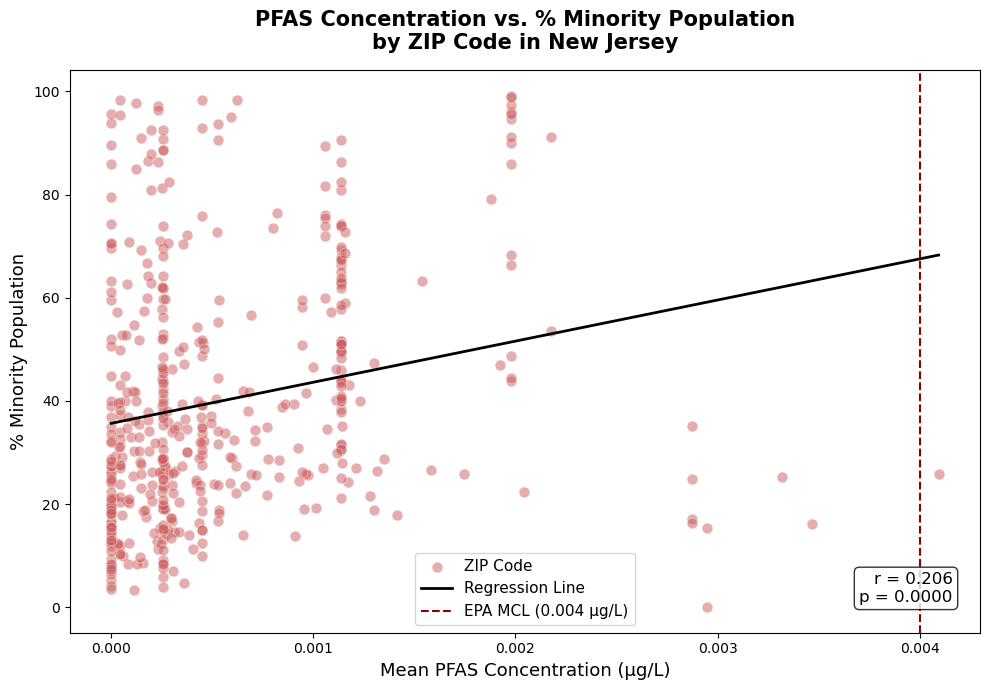

In [64]:
corr, pvalue = stats.pearsonr(pt_df['mean_pfas'], pt_df['pct_minority'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter points
ax.scatter(
    pt_df['mean_pfas'],
    pt_df['pct_minority'],
    color     = 'indianred',
    alpha     = 0.5,          # transparency so overlapping points are visible
    edgecolor = 'white',
    linewidth = 0.5,
    s         = 60,           # point size
    label     = 'ZIP Code'
)

# Regression line
m, b = np.polyfit(pt_df['mean_pfas'], pt_df['pct_minority'], 1)
x_line = np.linspace(pt_df['mean_pfas'].min(), pt_df['mean_pfas'].max(), 100)
ax.plot(x_line, m * x_line + b,
        color     = 'black',
        linewidth = 2,
        label     = 'Regression Line')

# EPA MCL vertical line
ax.axvline(x=0.004, color='darkred', linestyle='--', linewidth=1.5, label='EPA MCL (0.004 µg/L)')

# Labels and formatting
ax.set_xlabel('Mean PFAS Concentration (µg/L)', fontsize=13)
ax.set_ylabel('% Minority Population', fontsize=13)
ax.set_title('PFAS Concentration vs. % Minority Population\nby ZIP Code in New Jersey',
             fontsize=15, fontweight='bold', pad=15)

# Add r and p value as text on the plot
ax.text(
    0.97, 0.05,
    f'r = {corr:.3f}\np = {pvalue:.4f}',
    transform            = ax.transAxes,
    fontsize             = 12,
    verticalalignment    = 'bottom',
    horizontalalignment  = 'right',
    bbox                 = dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.legend(fontsize=11)
plt.tight_layout()

os.makedirs('output', exist_ok=True)
plt.savefig('output/pfas_vs_minority_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## T-Test

In [41]:
tt_df = map_df[['exceeds_mcl_mean', 'pct_minority']].dropna()
tt_df['pct_minority'] = pd.to_numeric(tt_df['pct_minority'], errors='coerce')
tt_df = tt_df.dropna()

exceeds     = tt_df[tt_df['exceeds_mcl_mean'] == True]['pct_minority']
not_exceeds = tt_df[tt_df['exceeds_mcl_mean'] == False]['pct_minority']

t_stat, pvalue = stats.ttest_ind(exceeds, not_exceeds)

print(f'Avg % minority in ZIPs EXCEEDING MCL:     {exceeds.mean():.1f}%')
print(f'Avg % minority in ZIPs NOT exceeding MCL: {not_exceeds.mean():.1f}%')
print(f'Difference:                               {exceeds.mean() - not_exceeds.mean():.1f}%')
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value:     {pvalue:.4f}')

Avg % minority in ZIPs EXCEEDING MCL:     25.8%
Avg % minority in ZIPs NOT exceeding MCL: 40.0%
Difference:                               -14.2%
T-statistic: -0.589
P-value:     0.5562
